# SGKAN Model Results for Different Datasets

In [7]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import optuna
import numpy as np
import pandas as pd
from scipy.stats import iqr
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

from sgkan import sgkan_model
import visualize
import swim as ss
import evaluation_metrics as em
random_seed = 0

In [8]:
def create_export_seed_results(seed_results, name):
    rows = []
    for i, r in enumerate(seed_results):
        rows.append({
            "seed": i,
            "train_mae": r["train"]["mae"],
            "train_rmse": r["train"]["rmse"],
            "train_inference_time_secs": r["train"]["inference_time_secs"],
            "test_mae": r["test"]["mae"],
            "test_rmse": r["test"]["rmse"],
            "test_inference_time_secs": r["test"]["inference_time_secs"],
        })

    seed_results_df = pd.DataFrame(rows)
    seed_results_df.to_csv(f"data/{name}.csv", index=False)
    return seed_results_df

def summarize_metrics(df, name):
    summary = {
        "model": name,
        "train_rmse_median": df["train_rmse"].median(),
        "train_rmse_iqr": iqr(df["train_rmse"]),
        "test_rmse_median": df["test_rmse"].median(),
        "test_rmse_iqr": iqr(df["test_rmse"]),
    }
    return summary


In [11]:
def load_dataset(dataset_prefix: str):
    # base data directory
    DATA_DIR = os.path.join(os.getcwd(), "..", "data")
    print(DATA_DIR)
    # load train and test set
    trn = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_trn.csv", delimiter=",")
    tst = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_tst.csv", delimiter=",")
    # slice train and test set
    x_train, y_train = trn[:, :-1], trn[:, -1]
    x_test,  y_test  = tst[:, :-1], tst[:, -1]
    
    print("x_train shape:", x_train.shape)
    print("y_train shape:", y_train.shape)
    print("x_test shape:", x_test.shape)
    print("y_test shape:", y_test.shape)

    return x_train, x_test, y_train, y_test

tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = load_dataset("tf1")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = load_dataset("tf2")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = load_dataset("tf3")
tf4_x_train, tf4_x_test, tf4_y_train, tf4_y_test = load_dataset("tf4")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = load_dataset("tf5")

/Users/gizemnurdal/Workspace/swim-meets-kans/../data


FileNotFoundError: [Errno 2] No such file or directory: '/Users/gizemnurdal/Workspace/swim-meets-kans/../data/TF1_trn.csv'

## TF1

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=500, D_in=2)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 587, 'interval': 413}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=500)
[fit_layer] local-window method counts over 500 edges: {'interval': 278, 'interval_capped': 220, 'knn_fallback': 2}
TF1 SGKAN train R2: 0.9999999371900504


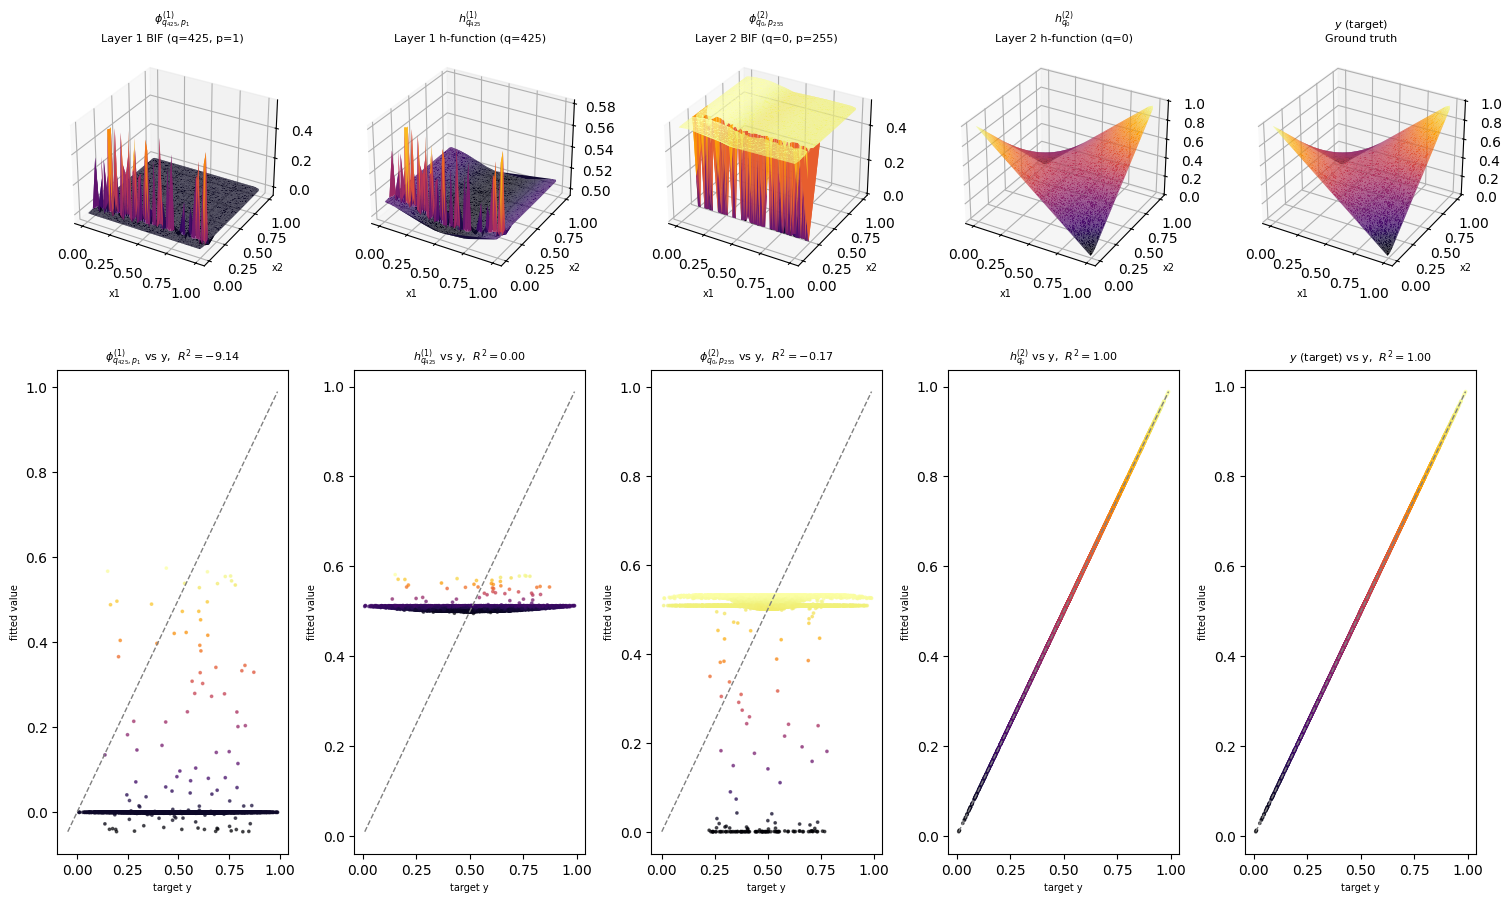

In [4]:
tf1_sgkan_layer_swim_configs = [
    {"layer_width": 500, "num_inducing": 50, "pair_selection_strategy": "swim", "alpha_edge": 1e-1, "alpha_neuron": 1e-6,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 50, "pair_selection_strategy": "swim", "alpha_edge": 1e-1, "alpha_neuron": 1e-6,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]

tf1_sgkan_stages, tf1_sgkan_ytrain_hat, tf1_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf1_x_train, tf1_y_train, tf1_sgkan_layer_swim_configs)
print("TF1 SGKAN train R2:", r2_score(tf1_y_train, tf1_sgkan_ytrain_hat))

visualize.plot_model_stages(tf1_x_train, tf1_y_train, tf1_sgkan_stages, block_idx="random", seed=0)
# visualize.plot_first_layer_featurewise_r2_summary_biased(tf1_sgkan_stages, tf1_y_train, tf1_sgkan_layer_neurons)

In [5]:
tf1_sgkan_layer_swim_configs = [
    {"layer_width": 500, "num_inducing": 50, "pair_selection_strategy": "swim", "alpha_edge": 1e-1, "alpha_neuron": 1e-6,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 50, "pair_selection_strategy": "swim", "alpha_edge": 1e-1, "alpha_neuron": 1e-6,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]


tf1_sgkan_model = sgkan_model.SGKANModel(tf1_sgkan_layer_swim_configs).fit(tf1_x_train, tf1_y_train)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=500, D_in=2)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 587, 'interval': 413}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=500)
[fit_layer] local-window method counts over 500 edges: {'interval': 278, 'interval_capped': 220, 'knn_fallback': 2}
[SGKANModel.fit] Total fit duration: 66.8167s


In [6]:
tf1_sgkan_results = em.evaluate(
    tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(tf1_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             3.063745e-05         3.949124e-05        
RMSE            4.168365e-05         6.853786e-05        
-------------------------------------------------------
Inference (s)   33.435054            7.923358            


In [7]:
tf1_sgkan_layer_random_configs = [
    {"layer_width": 500, "num_inducing": 50, "pair_selection_strategy": "random", "alpha_edge": 1e-1, "alpha_neuron": 1e-6,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed},
    {"layer_width": 1, "num_inducing": 50, "pair_selection_strategy": "random", "alpha_edge": 1e-1, "alpha_neuron": 1e-6,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed},
]

tf1_sgkan_model = sgkan_model.SGKANModel(tf1_sgkan_layer_random_configs).fit(tf1_x_train, tf1_y_train)

[fit_layer] pair_selection_strategy = 'random' (layer_width=500, D_in=2)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 612, 'interval': 387, 'knn_fallback': 1}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=500)
[fit_layer] local-window method counts over 500 edges: {'interval': 431, 'interval_capped': 65, 'knn_fallback': 4}
[SGKANModel.fit] Total fit duration: 7.0763s


In [8]:
tf1_sgkan_results = em.evaluate(
    tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(tf1_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.979540e-03         2.272013e-03        
RMSE            2.569892e-03         3.036769e-03        
-------------------------------------------------------
Inference (s)   4.909845             6.843635            


In [9]:
# total_seed = 50
# test_rmses = []
# seed_results = []
# for s in range(total_seed):
#     cfg = [
#         {**tf1_sgkan_layer_swim_configs[0], "seed": s},
#         {**tf1_sgkan_layer_swim_configs[1], "seed": s},
#     ]
#     model = sgkan_model.SGKANModel(cfg).fit(tf1_x_train, tf1_y_train)
#     results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
#     test_rmses.append(results["test"]["rmse"])
#     seed_results.append(results)

# print(f"Median: {np.median(test_rmses):.4e}, IQR: {np.percentile(test_rmses,75)-np.percentile(test_rmses,25):.4e}")

In [10]:
# create_export_seed_results(seed_results, name="tf1_sgkan_50_seeds_test")

## TF3

In [11]:
tf5_sgkan_layer_swim_configs = [
    {"layer_width": 600, "num_inducing": 50, "pair_selection_strategy": "swim", "alpha_edge": 1e-1, "alpha_neuron": 1e-6,
     "max_local_points": 1000, "kernel_type": "matern", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 50, "pair_selection_strategy": "swim", "alpha_edge": 1e-1, "alpha_neuron": 1e-6,
     "max_local_points": 1000, "kernel_type": "matern", "seed": random_seed, "sigma_scale": 1},
]

tf5_sgkan_model = sgkan_model.SGKANModel(tf5_sgkan_layer_swim_configs).fit(tf5_x_train, tf5_y_train)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=600, D_in=2)
[fit_layer] local-window method counts over 1200 edges: {'interval_capped': 647, 'interval': 553}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=600)
[fit_layer] local-window method counts over 600 edges: {'interval': 434, 'interval_capped': 166}
[SGKANModel.fit] Total fit duration: 9.0032s


In [12]:
tf5_sgkan_results = em.evaluate(
    tf5_sgkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(tf5_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             5.138049e-03         5.895802e-03        
RMSE            7.152544e-03         8.258095e-03        
-------------------------------------------------------
Inference (s)   5.725369             12.078020           
